In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [ ]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

params = [1.5, 1, 2, 1]
X0 = [0.2778, 1.5000] # dummy X0 for initialisation 

In [ ]:
model = ChebyKAN([2, 10, 2], 4)
kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 6, 0.007)

In [ ]:
fig, ax = plt.subplots()

def update(frame):
    kanODE.train(1)
    _, solution = kanODE.test()

    ax.clear()
    fig.legend(['x_data', 'y_data', 'x_KAN-ODE', 'y_KAN-ODE'])
    plt.ylabel('concentration')
    plt.xlabel('time')
    ax.set(xlim=[0, 20], ylim=[0, 5])
    plt.vlines(kanODE.trainingTime, 0, 5)
    ax.set_title(f"solution at frame: {frame}")
    ax.plot(kanODE.time, kanODE.baseSolution[:, 0].detach(), color='g')
    ax.plot(kanODE.time, kanODE.baseSolution[:, 1].detach(), color='b')
    ax.plot(solution[:, 0, 0].detach(), linestyle='dashed', color='g')
    ax.plot(solution[:, 0, 1].detach(), linestyle='dashed', color='b')

    return (ax)


In [ ]:
ani = animation.FuncAnimation(fig=fig, func=update, frames=10, interval=30)
ani.save("ringingAnim2.gif")

100%|██████████| 1/1 [00:00<00:00,  1.57it/s]


<Axes: title={'center': 'solution at frame: 1'}>

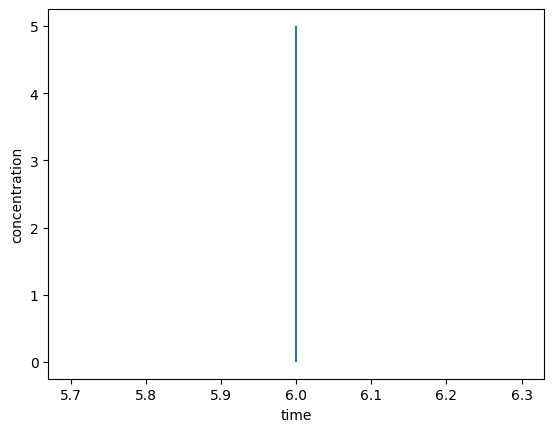

In [6]:
update(1)